# Basketball Dataset Preparation

This notebook is used to inspect, validate, clean, and merge multiple basketball object-detection datasets before training the final model.

The preparation process includes:

1. Inspecting dataset structure
2. Reading class mappings
3. Counting images and annotations
4. Merging datasets and unifying class IDs
5. Detecting missing files
6. Checking class distributions
7. Visualizing annotations
8. Identifying problematic samples
   → bad labels
   → invalid boxes
   → empty/problematic samples
   → corrupted images
9. Duplicate / near-duplicate detection
   → exact duplicates
   → similar frames
   → grouping related images

10. Creating the final cleaned dataset
   → remove problematic samples
   → create NEW train / valid / test split
   → preserve groups to prevent leakage

11. Final split validation
   → class distribution
   → sizes
   → leakage check

In [79]:
from pathlib import Path
import yaml
import cv2
import matplotlib.pyplot as plt
import random
import shutil
import csv
import numpy as np
from collections import Counter
import hashlib

# Paths to the original training datasets
training_dir = Path("data/training")

datasets = {
    "dataset_01": training_dir / "dataset_01",
    "dataset_02": training_dir / "dataset_02",
    "dataset_03": training_dir / "dataset_03",
}

for name, path in datasets.items():
    print(f"{name}: {path.exists()}")

dataset_01: True
dataset_02: True
dataset_03: True


## 1. Inspecting Dataset Structure

Check that each dataset contains the expected folders and files before further analysis.

In [5]:
from pathlib import Path

# Path to all downloaded datasets
training_dir = Path("data/training")

datasets = {
    "dataset_01": training_dir / "dataset_01",
    "dataset_02": training_dir / "dataset_02",
    "dataset_03": training_dir / "dataset_03",
}

# Expected split names
split_names = ["train", "valid", "val", "test"]

for dataset_name, dataset_path in datasets.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")
    
    # Check if the dataset folder exists
    print("Dataset path exists:", dataset_path.exists())
    
    # Check if data.yaml exists
    yaml_path = dataset_path / "data.yaml"
    print("data.yaml exists:", yaml_path.exists())
    
    # Check the available split folders
    for split_name in split_names:
        split_path = dataset_path / split_name
        
        if split_path.exists():
            print(f"\nFound split: {split_name}")
            print("images folder exists:", (split_path / "images").exists())
            print("labels folder exists:", (split_path / "labels").exists())


dataset_01
Dataset path exists: True
data.yaml exists: True

Found split: train
images folder exists: True
labels folder exists: True

Found split: valid
images folder exists: True
labels folder exists: True

Found split: test
images folder exists: True
labels folder exists: True

dataset_02
Dataset path exists: True
data.yaml exists: True

Found split: train
images folder exists: True
labels folder exists: True

Found split: valid
images folder exists: True
labels folder exists: True

Found split: test
images folder exists: True
labels folder exists: True

dataset_03
Dataset path exists: True
data.yaml exists: True

Found split: train
images folder exists: True
labels folder exists: True

Found split: valid
images folder exists: True
labels folder exists: True

Found split: test
images folder exists: True
labels folder exists: True


## 2. Reading Class Mappings

Read the class IDs and class names defined in each dataset.

In [6]:
# Read the class mapping from each dataset

for dataset_name, dataset_path in datasets.items():
    yaml_path = dataset_path / "data.yaml"

    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")

    if not yaml_path.exists():
        print("data.yaml not found")
        continue

    # Load the dataset configuration
    with open(yaml_path, "r", encoding="utf-8") as file:
        dataset_config = yaml.safe_load(file)

    # Read the class names
    class_names = dataset_config.get("names", {})

    print("Classes:")

    # Handle dictionary format
    if isinstance(class_names, dict):
        for class_id, class_name in class_names.items():
            print(f"{class_id}: {class_name}")

    # Handle list format
    elif isinstance(class_names, list):
        for class_id, class_name in enumerate(class_names):
            print(f"{class_id}: {class_name}")


dataset_01
Classes:
0: 0
1: 1
2: 2
3: 3
4: 4

dataset_02
Classes:
0: Ball
1: FG Attempt
2: FG Made
3: Hoop
4: Player
5: Ref

dataset_03
Classes:
0: ball
1: human
2: rim


### Dataset 01 Class Check

Dataset 01 does not provide meaningful class names, so its class IDs will be checked manually.

In [11]:
# Inspect the full configuration of dataset_01

dataset_01_yaml = datasets["dataset_01"] / "data.yaml"

with open(dataset_01_yaml, "r", encoding="utf-8") as file:
    dataset_01_config = yaml.safe_load(file)

print(dataset_01_config)

# Check README files in dataset_01

dataset_01_path = datasets["dataset_01"]

readme_files = [
    dataset_01_path / "README.dataset.txt",
    dataset_01_path / "README.roboflow.txt"
]

for readme_path in readme_files:
    print(f"\n{'=' * 50}")
    print(readme_path.name)
    print(f"{'=' * 50}")

    if readme_path.exists():
        with open(readme_path, "r", encoding="utf-8") as file:
            print(file.read())
    else:
        print("README file not found")

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 5, 'names': ['0', '1', '2', '3', '4'], 'roboflow': {'workspace': 'basketball-6vyfz', 'project': 'basketball-detection-srfkd', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/basketball-6vyfz/basketball-detection-srfkd/dataset/1'}}

README.dataset.txt
# Basketball detection > 2025-03-17 12:48am
https://universe.roboflow.com/basketball-6vyfz/basketball-detection-srfkd

Provided by a Roboflow user
License: CC BY 4.0



README.roboflow.txt

Basketball detection - v1 2025-03-17 12:48am

This dataset was exported via roboflow.com on March 22, 2025 at 8:27 AM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your d

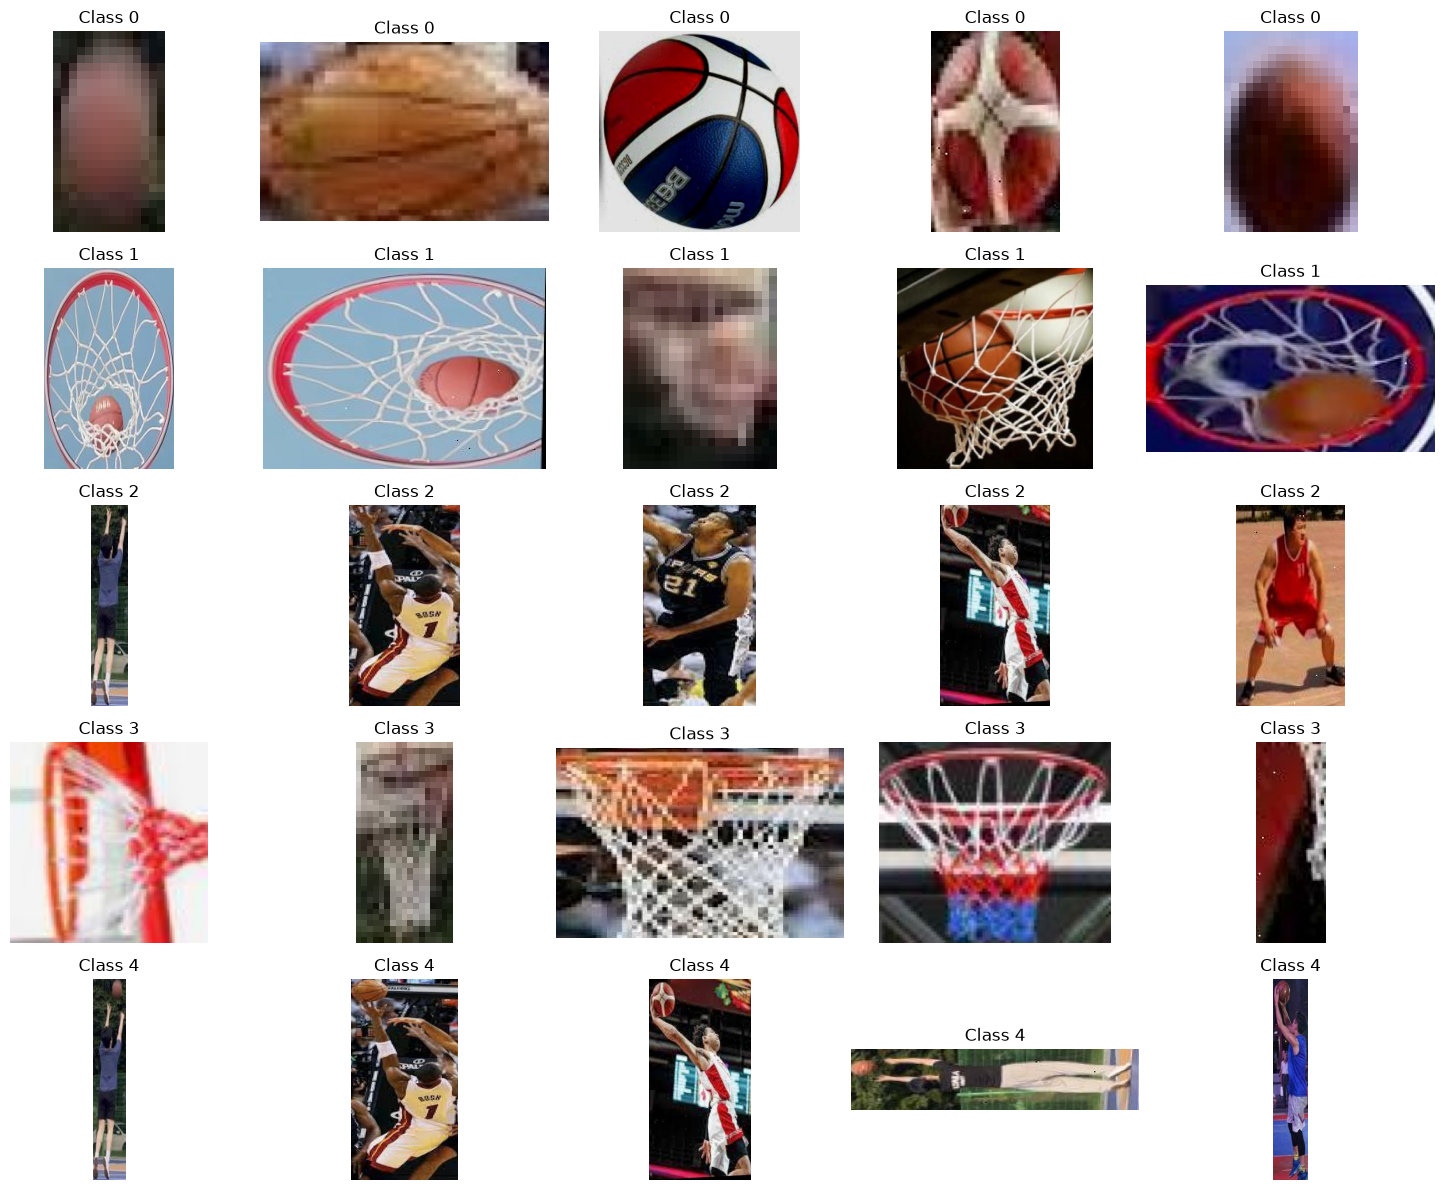

In [13]:
# Display multiple cropped examples for each class in dataset_01

import random

images_dir = datasets["dataset_01"] / "train" / "images"
labels_dir = datasets["dataset_01"] / "train" / "labels"

num_classes = 5
examples_per_class = 5

# Store multiple examples for each class
class_examples = {
    class_id: []
    for class_id in range(num_classes)
}

# Shuffle label files so we get different examples
label_files = list(labels_dir.glob("*.txt"))
random.shuffle(label_files)

for label_path in label_files:

    with open(label_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line in lines:
        values = line.strip().split()

        if len(values) < 5:
            continue

        class_id = int(values[0])

        # Skip if enough examples were already collected
        if len(class_examples[class_id]) >= examples_per_class:
            continue

        # Find the matching image
        image_path = None

        for extension in [".jpg", ".jpeg", ".png"]:
            candidate = images_dir / f"{label_path.stem}{extension}"

            if candidate.exists():
                image_path = candidate
                break

        if image_path is None:
            continue

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        height, width = image.shape[:2]

        x_center, y_center, box_width, box_height = map(
            float,
            values[1:5]
        )

        # Convert YOLO coordinates to pixel coordinates
        x1 = max(0, int((x_center - box_width / 2) * width))
        y1 = max(0, int((y_center - box_height / 2) * height))
        x2 = min(width, int((x_center + box_width / 2) * width))
        y2 = min(height, int((y_center + box_height / 2) * height))

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        class_examples[class_id].append(crop)

    # Stop once every class has enough examples
    if all(
        len(examples) >= examples_per_class
        for examples in class_examples.values()
    ):
        break


# Display the collected examples
plt.figure(figsize=(15, 12))

plot_index = 1

for class_id in range(num_classes):
    for crop in class_examples[class_id]:

        plt.subplot(
            num_classes,
            examples_per_class,
            plot_index
        )

        plt.imshow(crop)
        plt.title(f"Class {class_id}")
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

### Dataset 01 Class Mapping

The class mapping was verified manually using multiple annotated examples:

- **0** - Ball
- **1** - Ball in Basket
- **2** - Player
- **3** - Basket
- **4** - Player Shooting

### Dataset 03 Human Class Check

Inspect multiple `human` annotations to verify that they represent basketball players.

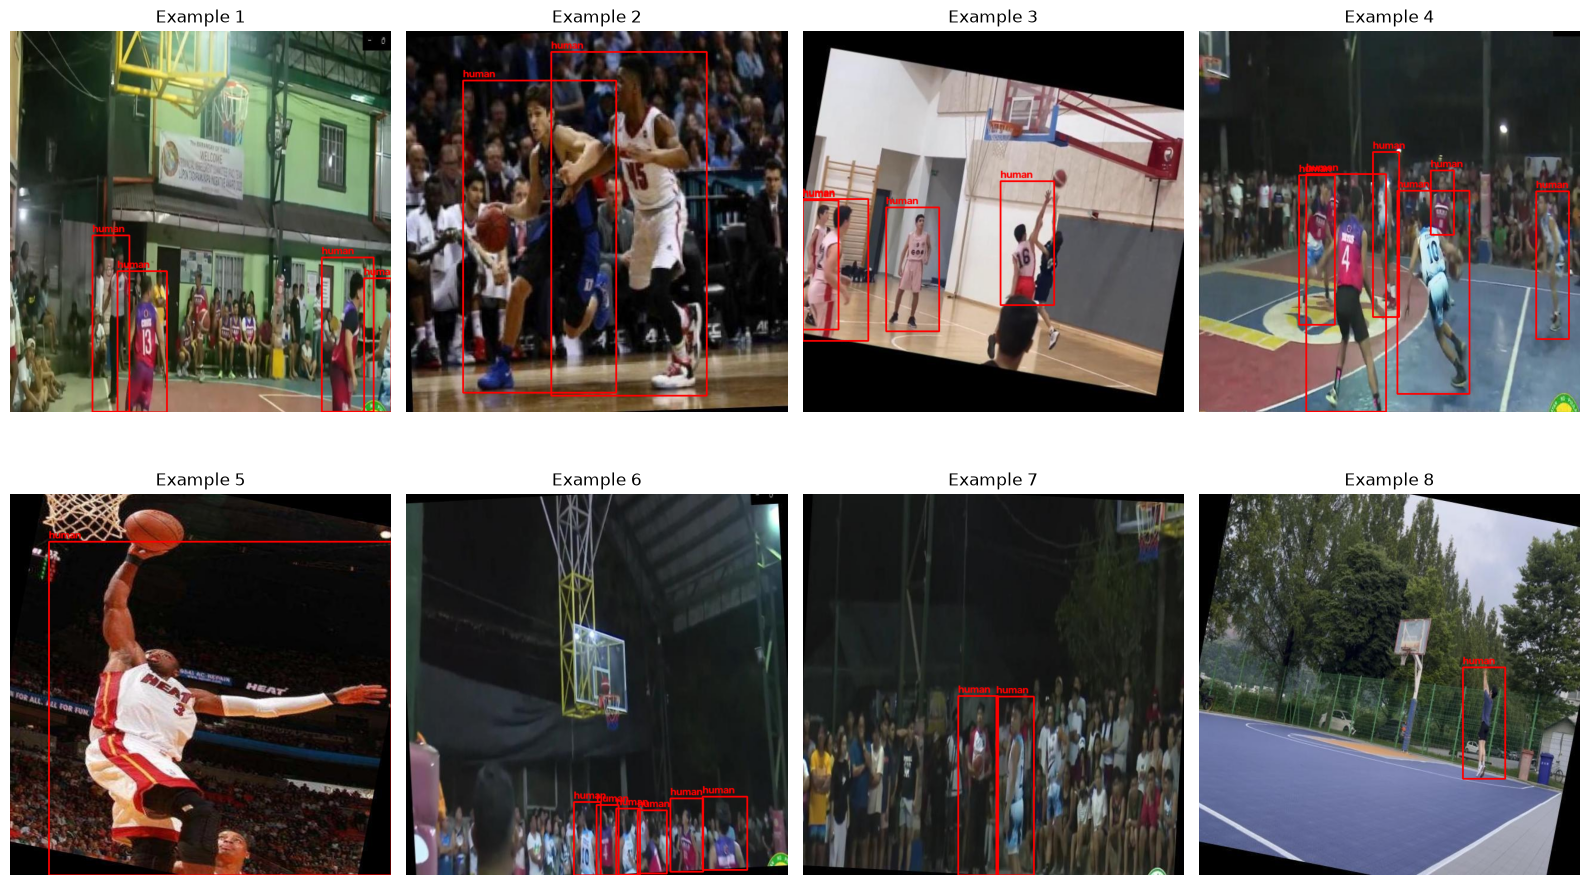

In [15]:
# Inspect the "human" class in dataset_03

import random

images_dir = datasets["dataset_03"] / "train" / "images"
labels_dir = datasets["dataset_03"] / "train" / "labels"

human_class_id = 1
examples_to_show = 8

# Find label files that contain the human class
human_labels = []

for label_path in labels_dir.glob("*.txt"):
    with open(label_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    if any(
        int(line.split()[0]) == human_class_id
        for line in lines
        if line.strip()
    ):
        human_labels.append(label_path)

# Select random examples
sample_labels = random.sample(
    human_labels,
    min(examples_to_show, len(human_labels))
)

plt.figure(figsize=(16, 10))

for index, label_path in enumerate(sample_labels, start=1):

    # Find the matching image
    image_path = None

    for extension in [".jpg", ".jpeg", ".png"]:
        candidate = images_dir / f"{label_path.stem}{extension}"

        if candidate.exists():
            image_path = candidate
            break

    if image_path is None:
        continue

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width = image.shape[:2]

    with open(label_path, "r", encoding="utf-8") as file:
        for line in file:
            values = line.strip().split()

            if len(values) < 5:
                continue

            class_id = int(values[0])

            # Draw only human annotations
            if class_id != human_class_id:
                continue

            x_center, y_center, box_width, box_height = map(
                float,
                values[1:5]
            )

            x1 = int((x_center - box_width / 2) * width)
            y1 = int((y_center - box_height / 2) * height)
            x2 = int((x_center + box_width / 2) * width)
            y2 = int((y_center + box_height / 2) * height)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                image,
                "human",
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    plt.subplot(2, 4, index)
    plt.imshow(image)
    plt.title(f"Example {index}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Selected Class Examples

Compare examples of the classes that will be mapped to `basketball`, `hoop`, and `player`.

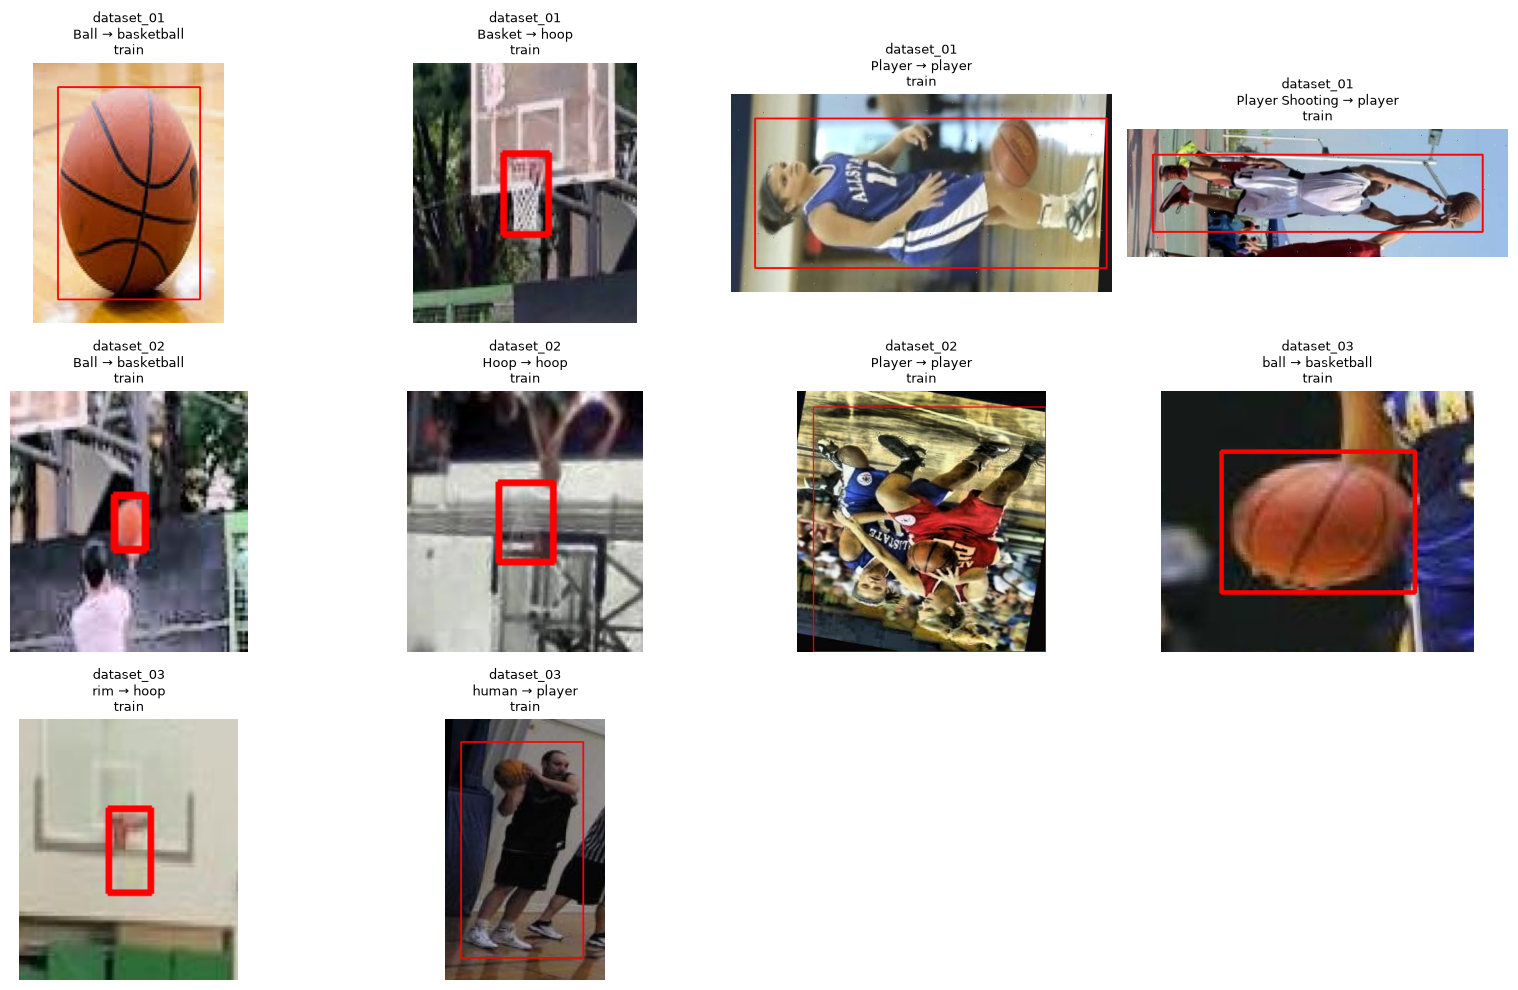

In [25]:
# Class IDs that will be used from each dataset

selected_classes = {
    "dataset_01": {
        0: "Ball → basketball",
        3: "Basket → hoop",
        2: "Player → player",
        4: "Player Shooting → player"
    },
    "dataset_02": {
        0: "Ball → basketball",
        3: "Hoop → hoop",
        4: "Player → player"
    },
    "dataset_03": {
        0: "ball → basketball",
        2: "rim → hoop",
        1: "human → player"
    }
}


def get_class_crop(dataset_path, class_id, padding=40):
    # Search for the class across all available dataset splits
    for split_name in ["train", "valid", "test"]:

        images_dir = dataset_path / split_name / "images"
        labels_dir = dataset_path / split_name / "labels"

        if not images_dir.exists() or not labels_dir.exists():
            continue

        label_files = list(labels_dir.glob("*.txt"))
        random.shuffle(label_files)

        for label_path in label_files:
            with open(label_path, "r", encoding="utf-8") as file:
                for line in file:
                    values = line.strip().split()

                    if len(values) < 5:
                        continue

                    current_class_id = int(values[0])

                    if current_class_id != class_id:
                        continue

                    # Find the matching image
                    image_path = None

                    for extension in [".jpg", ".jpeg", ".png"]:
                        candidate = images_dir / f"{label_path.stem}{extension}"

                        if candidate.exists():
                            image_path = candidate
                            break

                    if image_path is None:
                        continue

                    image = cv2.imread(str(image_path))

                    if image is None:
                        continue

                    height, width = image.shape[:2]

                    x_center, y_center, box_width, box_height = map(
                        float,
                        values[1:5]
                    )

                    # Convert YOLO coordinates to pixels
                    x1 = int((x_center - box_width / 2) * width)
                    y1 = int((y_center - box_height / 2) * height)
                    x2 = int((x_center + box_width / 2) * width)
                    y2 = int((y_center + box_height / 2) * height)

                    # Add context around the object
                    crop_x1 = max(0, x1 - padding)
                    crop_y1 = max(0, y1 - padding)
                    crop_x2 = min(width, x2 + padding)
                    crop_y2 = min(height, y2 + padding)

                    crop = image[
                        crop_y1:crop_y2,
                        crop_x1:crop_x2
                    ].copy()

                    if crop.size == 0:
                        continue

                    # Draw the original annotation box
                    cv2.rectangle(
                        crop,
                        (x1 - crop_x1, y1 - crop_y1),
                        (x2 - crop_x1, y2 - crop_y1),
                        (0, 0, 255),
                        2
                    )

                    crop = cv2.cvtColor(
                        crop,
                        cv2.COLOR_BGR2RGB
                    )

                    return crop, split_name

    return None, None


# Display selected class examples
plt.figure(figsize=(16, 10))

plot_index = 1

for dataset_name, classes in selected_classes.items():
    for class_id, description in classes.items():

        crop, split_name = get_class_crop(
            datasets[dataset_name],
            class_id
        )

        plt.subplot(3, 4, plot_index)

        if crop is not None:
            plt.imshow(crop)

        plt.title(
            f"{dataset_name}\n{description}\n{split_name}",
            fontsize=9
        )

        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

### Unused Class Examples

Inspect the classes that are currently excluded from the final detector.

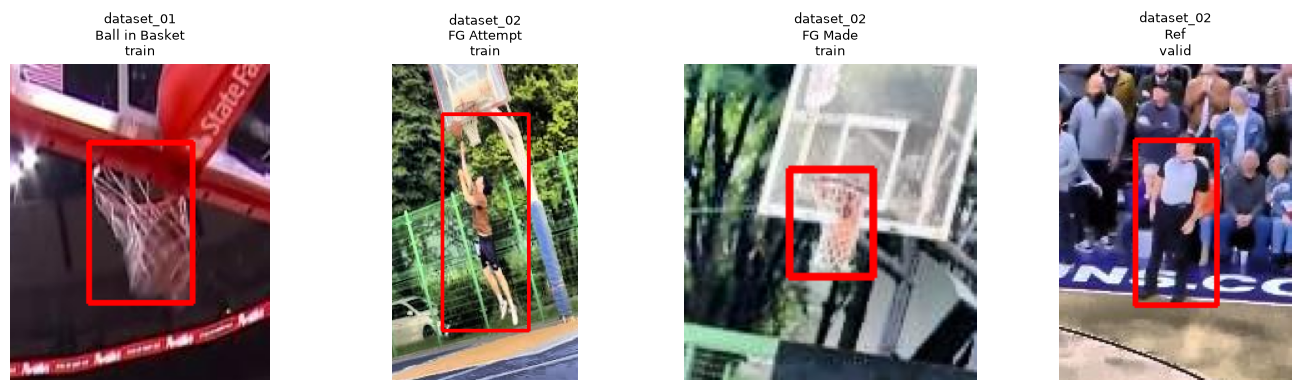

In [27]:
# Classes that are not currently planned for the final detector

unused_classes = {
    "dataset_01": {
        1: "Ball in Basket"
    },
    "dataset_02": {
        1: "FG Attempt",
        2: "FG Made",
        5: "Ref"
    }
}

total_unused = sum(
    len(classes)
    for classes in unused_classes.values()
)

plt.figure(figsize=(14, 4))

plot_index = 1

for dataset_name, classes in unused_classes.items():
    for class_id, class_name in classes.items():

        crop, split_name = get_class_crop(
            datasets[dataset_name],
            class_id
        )

        plt.subplot(1, total_unused, plot_index)

        if crop is not None:
            plt.imshow(crop)

        plt.title(
            f"{dataset_name}\n{class_name}\n{split_name}",
            fontsize=9
        )

        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

### Target Classes

The final detector will focus on three object classes:

- **Basketball**
- **Hoop**
- **Player**

Dataset-specific classes will be reviewed and mapped to these classes where appropriate.

## 3. Counting Images and Annotations

Check the image and annotation distribution across all dataset splits before merging.

In [28]:
# Final class mapping for each dataset
class_mapping = {
    "dataset_01": {
        0: 0,  # Ball -> basketball
        3: 1,  # Basket -> hoop
        2: 2,  # Player -> player
        4: 2   # Player Shooting -> player
    },
    "dataset_02": {
        0: 0,  # Ball -> basketball
        3: 1,  # Hoop -> hoop
        4: 2   # Player -> player
    },
    "dataset_03": {
        0: 0,  # ball -> basketball
        2: 1,  # rim -> hoop
        1: 2   # human -> player
    }
}

final_class_names = {
    0: "basketball",
    1: "hoop",
    2: "player"
}


# Check every dataset split
for dataset_name, dataset_path in datasets.items():

    print(f"\n{'=' * 60}")
    print(dataset_name)
    print(f"{'=' * 60}")

    for split_name in ["train", "valid", "test"]:

        images_dir = dataset_path / split_name / "images"
        labels_dir = dataset_path / split_name / "labels"

        if not images_dir.exists() or not labels_dir.exists():
            print(f"\n{split_name}: split not found")
            continue

        # Count images
        image_count = sum(
            1
            for path in images_dir.iterdir()
            if path.suffix.lower() in [".jpg", ".jpeg", ".png"]
        )

        # Count mapped annotations
        class_counts = {
            0: 0,
            1: 0,
            2: 0
        }

        for label_path in labels_dir.glob("*.txt"):

            with open(label_path, "r", encoding="utf-8") as file:
                for line in file:

                    values = line.strip().split()

                    if not values:
                        continue

                    original_class_id = int(values[0])

                    # Ignore classes that are not used
                    if original_class_id not in class_mapping[dataset_name]:
                        continue

                    final_class_id = class_mapping[dataset_name][original_class_id]

                    class_counts[final_class_id] += 1

        print(f"\n{split_name}")
        print(f"Images: {image_count}")

        for class_id, class_name in final_class_names.items():
            print(f"{class_name}: {class_counts[class_id]}")


dataset_01

train
Images: 9599
basketball: 9485
hoop: 6490
player: 20257

valid
Images: 873
basketball: 876
hoop: 600
player: 1854

test
Images: 436
basketball: 464
hoop: 290
player: 950

dataset_02

train
Images: 16240
basketball: 15931
hoop: 10898
player: 35000

valid
Images: 203
basketball: 161
hoop: 105
player: 654

test
Images: 111
basketball: 39
hoop: 94
player: 71

dataset_03

train
Images: 6662
basketball: 6708
hoop: 4726
player: 14448

valid
Images: 1893
basketball: 1918
hoop: 1345
player: 4227

test
Images: 960
basketball: 971
hoop: 673
player: 1972


## 4. Merging Datasets and Unifying Class IDs

Merge all dataset splits while converting the selected classes to a shared class mapping.

In [54]:
# ============================================================
# Merge all datasets into one unified data pool
# ============================================================

merged_root = Path("data/merged/basketball_dataset_temp")

source_splits = ["train", "valid", "test"]

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# Recreate the temporary merged dataset from scratch.
# The original datasets are not modified.
if merged_root.exists():
    shutil.rmtree(merged_root)

output_images_dir = merged_root / "images"
output_labels_dir = merged_root / "labels"

output_images_dir.mkdir(parents=True, exist_ok=True)
output_labels_dir.mkdir(parents=True, exist_ok=True)


# Store the original source of every merged image
manifest_rows = []

# Store overall merge statistics
merge_stats = {
    "images": 0,
    "labels": 0,
    "basketball": 0,
    "hoop": 0,
    "player": 0,
    "dropped_annotations": 0,
    "empty_labels": 0,
    "invalid_annotations": 0,
    "missing_labels": 0
}


for dataset_name, dataset_path in datasets.items():

    for source_split in source_splits:

        images_dir = dataset_path / source_split / "images"
        labels_dir = dataset_path / source_split / "labels"

        if not images_dir.exists():
            continue

        # ----------------------------------------------------
        # Process every image and its matching label
        # ----------------------------------------------------

        for image_path in images_dir.iterdir():

            if (
                not image_path.is_file()
                or image_path.suffix.lower() not in image_extensions
            ):
                continue

            # Include both dataset and original split in the name
            # to prevent filename collisions.
            new_stem = (
                f"{dataset_name}__"
                f"{source_split}__"
                f"{image_path.stem}"
            )

            output_image_path = (
                output_images_dir
                / f"{new_stem}{image_path.suffix.lower()}"
            )

            output_label_path = (
                output_labels_dir
                / f"{new_stem}.txt"
            )

            shutil.copy2(
                image_path,
                output_image_path
            )

            original_label_path = (
                labels_dir
                / f"{image_path.stem}.txt"
            )

            converted_lines = []

            # ------------------------------------------------
            # Convert annotations to the unified class mapping
            # ------------------------------------------------

            if original_label_path.exists():

                with open(
                    original_label_path,
                    "r",
                    encoding="utf-8"
                ) as file:

                    for line in file:

                        values = line.strip().split()

                        # A YOLO detection should contain:
                        # class_id, x_center, y_center, width, height
                        if len(values) != 5:
                            merge_stats[
                                "invalid_annotations"
                            ] += 1
                            continue

                        try:
                            original_class_id = int(values[0])

                            # Validate coordinate values as numbers
                            list(map(float, values[1:]))

                        except ValueError:
                            merge_stats[
                                "invalid_annotations"
                            ] += 1
                            continue

                        # Ignore classes that are not part
                        # of the final detector.
                        if (
                            original_class_id
                            not in class_mapping[dataset_name]
                        ):
                            merge_stats[
                                "dropped_annotations"
                            ] += 1
                            continue

                        # Convert to the unified class ID
                        final_class_id = class_mapping[
                            dataset_name
                        ][original_class_id]

                        converted_line = " ".join(
                            [str(final_class_id)] + values[1:]
                        )

                        converted_lines.append(
                            converted_line
                        )

                        if final_class_id == 0:
                            merge_stats["basketball"] += 1

                        elif final_class_id == 1:
                            merge_stats["hoop"] += 1

                        elif final_class_id == 2:
                            merge_stats["player"] += 1

            else:
                merge_stats["missing_labels"] += 1

            # Keep an empty label file when no selected
            # annotations remain or when the original label
            # is missing. QA will inspect these later.
            with open(
                output_label_path,
                "w",
                encoding="utf-8"
            ) as file:

                if converted_lines:
                    file.write(
                        "\n".join(converted_lines) + "\n"
                    )

            if not converted_lines:
                merge_stats["empty_labels"] += 1

            merge_stats["images"] += 1
            merge_stats["labels"] += 1

            # Save provenance only as metadata.
            # The original split no longer has any training meaning.
            manifest_rows.append({
                "merged_file": output_image_path.name,
                "source_dataset": dataset_name,
                "source_split": source_split,
                "source_file": image_path.name,
                "label_exists": original_label_path.exists()
            })


# ============================================================
# Save source manifest
# ============================================================

manifest_path = merged_root / "source_manifest.csv"

with open(
    manifest_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "merged_file",
            "source_dataset",
            "source_split",
            "source_file",
            "label_exists"
        ]
    )

    writer.writeheader()
    writer.writerows(manifest_rows)


# ============================================================
# Display merge summary
# ============================================================

print("Unified dataset pool created:")
print(merged_root)

print(f"\n{'=' * 50}")
print("MERGE SUMMARY")
print(f"{'=' * 50}")

print("Images:", merge_stats["images"])
print("Labels:", merge_stats["labels"])
print("Basketball:", merge_stats["basketball"])
print("Hoop:", merge_stats["hoop"])
print("Player:", merge_stats["player"])

print(
    "Dropped annotations:",
    merge_stats["dropped_annotations"]
)

print(
    "Empty labels after mapping:",
    merge_stats["empty_labels"]
)

print(
    "Missing original labels:",
    merge_stats["missing_labels"]
)

print(
    "Invalid annotations:",
    merge_stats["invalid_annotations"]
)

print("\nSource manifest:")
print(manifest_path)

Unified dataset pool created:
data\merged\basketball_dataset_temp

MERGE SUMMARY
Images: 36977
Labels: 36977
Basketball: 36552
Hoop: 25221
Player: 79432
Dropped annotations: 5618
Empty labels after mapping: 295
Missing original labels: 0
Invalid annotations: 2

Source manifest:
data\merged\basketball_dataset_temp\source_manifest.csv


### Merge Summary

The three datasets were successfully merged using the unified `basketball`, `hoop`, and `player` class mapping.

No invalid annotations were found. Images with empty labels after class filtering will be reviewed during the cleaning process.

## 5. Detecting Missing Files

Check for missing image-label pairs in the merged dataset.

In [56]:
# Check for missing image-label pairs in the unified dataset

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

images_dir = merged_root / "images"
labels_dir = merged_root / "labels"

# Collect image filenames without extensions
image_stems = {
    path.stem
    for path in images_dir.iterdir()
    if path.suffix.lower() in image_extensions
}

# Collect label filenames without extensions
label_stems = {
    path.stem
    for path in labels_dir.glob("*.txt")
}

# Find unmatched files
images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print(f"Images: {len(image_stems)}")
print(f"Labels: {len(label_stems)}")
print(f"Images without labels: {len(images_without_labels)}")
print(f"Labels without images: {len(labels_without_images)}")

Images: 36977
Labels: 36977
Images without labels: 0
Labels without images: 0


## 6. Checking Class Distributions

Analyze the distribution of `basketball`, `hoop`, and `player` annotations across all dataset splits.

In [57]:
from collections import Counter

# Final unified classes
class_names = {
    0: "basketball",
    1: "hoop",
    2: "player"
}

labels_dir = merged_root / "labels"

counts = Counter()

# Count all annotations in the unified dataset
for label_path in labels_dir.glob("*.txt"):

    with open(label_path, "r", encoding="utf-8") as file:

        for line in file:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])

            if class_id in class_names:
                counts[class_id] += 1


total_annotations = sum(counts.values())

print(f"{'=' * 50}")
print("UNIFIED DATASET")
print(f"{'=' * 50}")

for class_id, class_name in class_names.items():

    count = counts[class_id]

    percentage = (
        count / total_annotations * 100
        if total_annotations > 0
        else 0
    )

    print(
        f"{class_name}: "
        f"{count} ({percentage:.2f}%)"
    )

print(f"\nTotal annotations: {total_annotations}")

UNIFIED DATASET
basketball: 36552 (25.89%)
hoop: 25221 (17.86%)
player: 79432 (56.25%)

Total annotations: 141205


### Class Distribution Summary

The class distribution is consistent across the train, validation, and test splits. Players are the most common class, which is expected in basketball scenes.

## 7. Visualizing Annotations

Visualize random annotated samples from each split to verify bounding boxes and class labels.

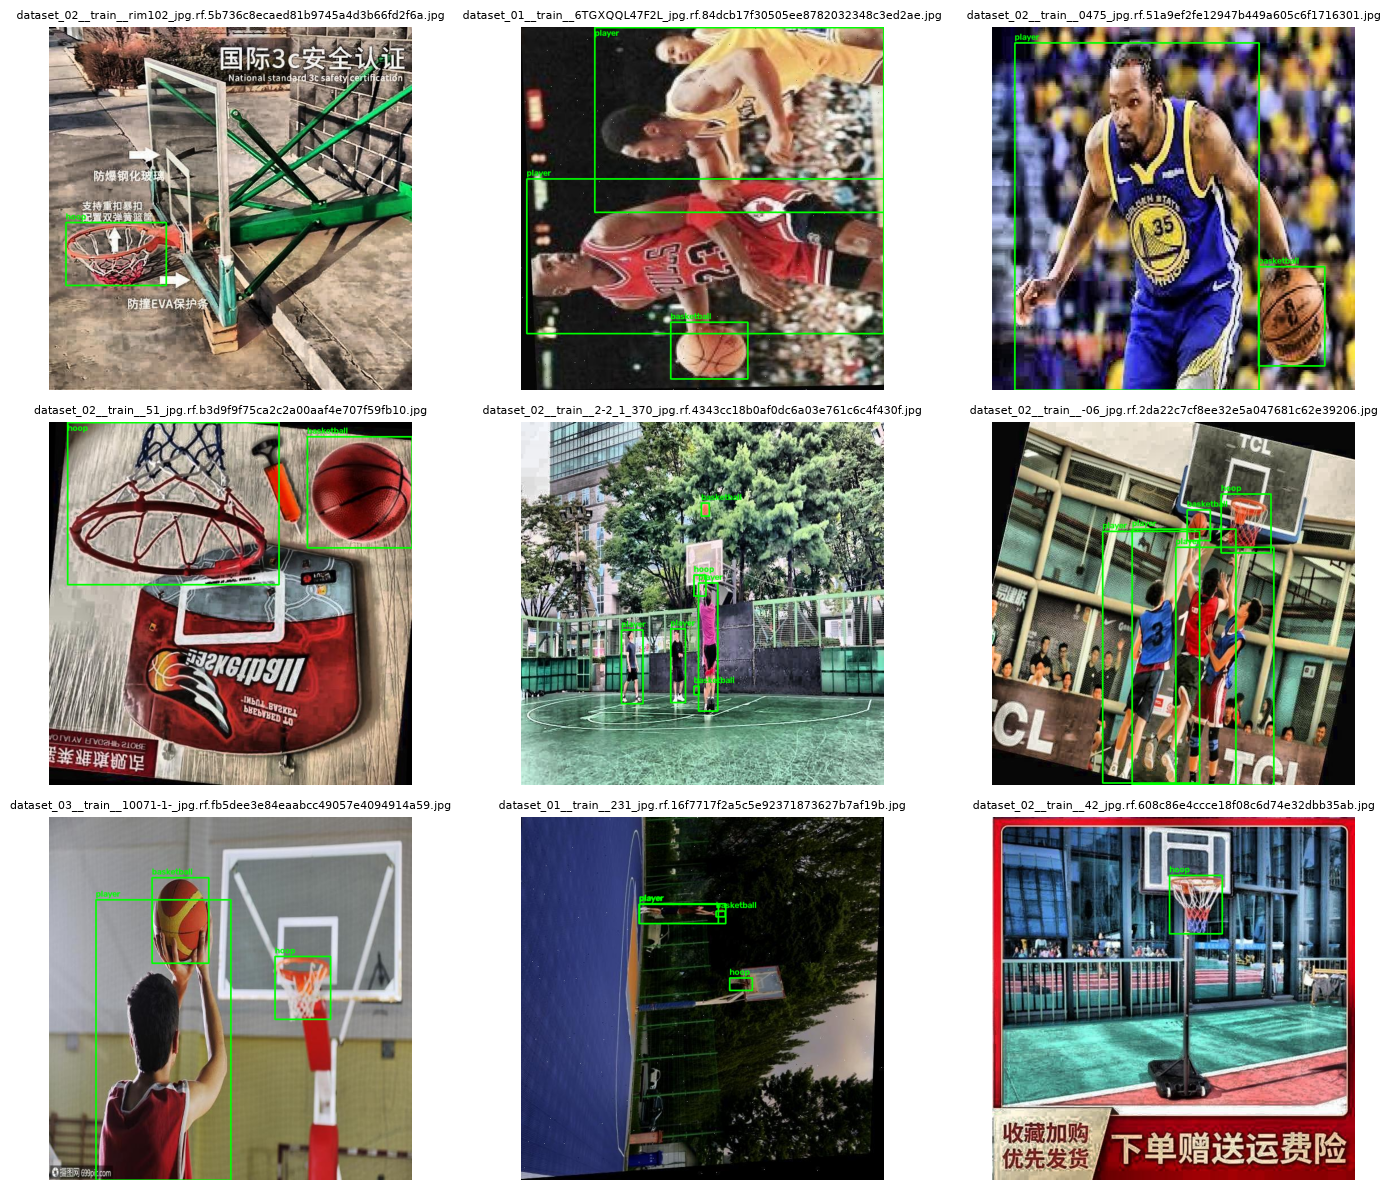

In [59]:
# Visualize random annotated samples from the unified dataset

class_names = {
    0: "basketball",
    1: "hoop",
    2: "player"
}

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def draw_annotations(image_path, label_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return None

    height, width = image.shape[:2]

    if label_path.exists():

        with open(label_path, "r", encoding="utf-8") as file:

            for line in file:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id = int(values[0])
                x_center = float(values[1])
                y_center = float(values[2])
                box_width = float(values[3])
                box_height = float(values[4])

                # Convert normalized YOLO coordinates to pixel coordinates
                x1 = int((x_center - box_width / 2) * width)
                y1 = int((y_center - box_height / 2) * height)
                x2 = int((x_center + box_width / 2) * width)
                y2 = int((y_center + box_height / 2) * height)

                class_name = class_names.get(
                    class_id,
                    str(class_id)
                )

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                # Draw class name
                cv2.putText(
                    image,
                    class_name,
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

    return cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )


images_dir = merged_root / "images"
labels_dir = merged_root / "labels"

image_paths = [
    path
    for path in images_dir.iterdir()
    if path.suffix.lower() in image_extensions
]

# Select 9 random images from the unified dataset
selected_images = random.sample(
    image_paths,
    min(9, len(image_paths))
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12)
)

axes = axes.flatten()

for index, image_path in enumerate(selected_images):

    label_path = (
        labels_dir
        / f"{image_path.stem}.txt"
    )

    image = draw_annotations(
        image_path,
        label_path
    )

    axes[index].imshow(image)

    axes[index].set_title(
        image_path.name,
        fontsize=8
    )

    axes[index].axis("off")


# Hide unused cells if fewer than 9 images are available
for index in range(len(selected_images), len(axes)):
    axes[index].axis("off")


plt.tight_layout()
plt.show()

## 8. Identifying Problematic Samples

Scan the merged dataset for corrupted images, empty labels, invalid boxes, duplicate annotations, and extreme annotation cases.

In [60]:
annotations_per_image = []

labels_dir = merged_root / "labels"

for label_path in labels_dir.glob("*.txt"):

    with open(label_path, "r", encoding="utf-8") as file:
        annotation_count = sum(
            1 for line in file
            if line.strip()
        )

    annotations_per_image.append(annotation_count)


annotations_per_image = np.array(annotations_per_image)

print(f"Images: {len(annotations_per_image)}")
print(f"Average annotations/image: {annotations_per_image.mean():.2f}")
print(f"Median: {np.median(annotations_per_image):.0f}")
print(f"95th percentile: {np.percentile(annotations_per_image, 95):.0f}")
print(f"99th percentile: {np.percentile(annotations_per_image, 99):.0f}")
print(f"Maximum: {annotations_per_image.max()}")

Images: 36977
Average annotations/image: 3.82
Median: 3
95th percentile: 9
99th percentile: 11
Maximum: 49


In [61]:
thresholds = [11, 15, 20, 30, 40]

for threshold in thresholds:
    count = np.sum(annotations_per_image > threshold)

    print(
        f"More than {threshold}: "
        f"{count} images "
        f"({count / len(annotations_per_image) * 100:.2f}%)"
    )

More than 11: 333 images (0.90%)
More than 15: 48 images (0.13%)
More than 20: 24 images (0.06%)
More than 30: 2 images (0.01%)
More than 40: 2 images (0.01%)


In [62]:
resolution_data = []

images_dir = merged_root / "images"

for image_path in images_dir.iterdir():

    if image_path.suffix.lower() not in image_extensions:
        continue

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    height, width = image.shape[:2]

    resolution_data.append({
        "image": image_path.name,
        "width": width,
        "height": height,
        "pixels": width * height,
        "aspect_ratio": width / height
    })

In [63]:
widths = np.array([item["width"] for item in resolution_data])
heights = np.array([item["height"] for item in resolution_data])

print(f"Images: {len(resolution_data)}")

print("\nWidth:")
print(f"Minimum: {widths.min()}")
print(f"Median: {np.median(widths):.0f}")
print(f"95th percentile: {np.percentile(widths, 95):.0f}")
print(f"Maximum: {widths.max()}")

print("\nHeight:")
print(f"Minimum: {heights.min()}")
print(f"Median: {np.median(heights):.0f}")
print(f"95th percentile: {np.percentile(heights, 95):.0f}")
print(f"Maximum: {heights.max()}")

Images: 36977

Width:
Minimum: 640
Median: 640
95th percentile: 640
Maximum: 640

Height:
Minimum: 360
Median: 640
95th percentile: 640
Maximum: 640


In [64]:
from collections import Counter

resolution_counts = Counter(
    (item["width"], item["height"])
    for item in resolution_data
)

print("\nMost common resolutions:")

for (width, height), count in resolution_counts.most_common(10):
    print(f"{width}x{height}: {count}")


Most common resolutions:
640x640: 36899
640x360: 78


### Bounding Box Size Analysis

Analyze bounding box sizes in pixels to identify unusually small annotations.

In [65]:
# Map each image to its resolution
resolution_map = {
    Path(item["image"]).stem: (item["width"], item["height"])
    for item in resolution_data
}

box_sizes = {
    0: [],  # basketball
    1: [],  # hoop
    2: []   # player
}

labels_dir = merged_root / "labels"

for label_path in labels_dir.glob("*.txt"):

    key = label_path.stem

    if key not in resolution_map:
        continue

    image_width, image_height = resolution_map[key]

    with open(label_path, "r", encoding="utf-8") as file:

        for line in file:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])

            box_width = float(values[3]) * image_width
            box_height = float(values[4]) * image_height

            min_side = min(
                box_width,
                box_height
            )

            if class_id in box_sizes:
                box_sizes[class_id].append(min_side)


class_names = {
    0: "basketball",
    1: "hoop",
    2: "player"
}

for class_id, sizes in box_sizes.items():

    sizes = np.array(sizes)

    print(f"\n{'=' * 50}")
    print(class_names[class_id])
    print(f"{'=' * 50}")

    print(f"Annotations: {len(sizes)}")
    print(f"Minimum: {sizes.min():.2f} px")
    print(f"1st percentile: {np.percentile(sizes, 1):.2f} px")
    print(f"5th percentile: {np.percentile(sizes, 5):.2f} px")
    print(f"Median: {np.median(sizes):.2f} px")


basketball
Annotations: 36552
Minimum: 4.00 px
1st percentile: 7.50 px
5th percentile: 9.00 px
Median: 36.00 px

hoop
Annotations: 25221
Minimum: 4.00 px
1st percentile: 17.00 px
5th percentile: 18.50 px
Median: 42.50 px

player
Annotations: 79432
Minimum: 1.00 px
1st percentile: 19.00 px
5th percentile: 26.00 px
Median: 71.00 px


In [66]:
candidate_thresholds = {
    0: [4, 5, 6, 7],          # basketball
    1: [4, 8, 12, 15, 17],    # hoop
    2: [1, 2, 4, 8, 12, 16]   # player
}

for class_id, thresholds in candidate_thresholds.items():

    sizes = np.array(box_sizes[class_id])

    print(f"\n{class_names[class_id]}")

    for threshold in thresholds:
        count = np.sum(sizes <= threshold)

        print(
            f"<= {threshold}px: "
            f"{count} annotations "
            f"({count / len(sizes) * 100:.3f}%)"
        )


basketball
<= 4px: 8 annotations (0.022%)
<= 5px: 79 annotations (0.216%)
<= 6px: 192 annotations (0.525%)
<= 7px: 347 annotations (0.949%)

hoop
<= 4px: 1 annotations (0.004%)
<= 8px: 13 annotations (0.052%)
<= 12px: 69 annotations (0.274%)
<= 15px: 176 annotations (0.698%)
<= 17px: 551 annotations (2.185%)

player
<= 1px: 1 annotations (0.001%)
<= 2px: 2 annotations (0.003%)
<= 4px: 8 annotations (0.010%)
<= 8px: 52 annotations (0.065%)
<= 12px: 130 annotations (0.164%)
<= 16px: 372 annotations (0.468%)


### Tiny Box Analysis

Very small bounding boxes were analyzed separately for each class. Based on the observed distribution, the following thresholds were selected for manual review:

- `basketball`: <= 6 px
- `hoop`: <= 12 px
- `player`: <= 8 px

Samples below these thresholds will be flagged for review, not removed automatically.

In [67]:
box_area_ratios = {
    0: [],  # basketball
    1: [],  # hoop
    2: []   # player
}

labels_dir = merged_root / "labels"

for label_path in labels_dir.glob("*.txt"):

    with open(label_path, "r", encoding="utf-8") as file:

        for line in file:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])
            box_width = float(values[3])
            box_height = float(values[4])

            # YOLO width and height are normalized,
            # so their product is the fraction of the image area.
            area_ratio = box_width * box_height

            if class_id in box_area_ratios:
                box_area_ratios[class_id].append(area_ratio)


for class_id, ratios in box_area_ratios.items():

    ratios = np.array(ratios)

    print(f"\n{'=' * 50}")
    print(class_names[class_id])
    print(f"{'=' * 50}")

    print(f"Maximum: {ratios.max() * 100:.2f}%")
    print(f"99th percentile: {np.percentile(ratios, 99) * 100:.2f}%")
    print(f"95th percentile: {np.percentile(ratios, 95) * 100:.2f}%")
    print(f"Median: {np.median(ratios) * 100:.2f}%")


basketball
Maximum: 100.00%
99th percentile: 100.00%
95th percentile: 56.70%
Median: 0.47%

hoop
Maximum: 100.00%
99th percentile: 72.82%
95th percentile: 36.90%
Median: 0.70%

player
Maximum: 100.00%
99th percentile: 76.87%
95th percentile: 50.82%
Median: 3.66%


In [68]:
area_thresholds = [0.50, 0.75, 0.90, 0.95, 0.99]

for class_id, thresholds in {
    0: area_thresholds,
    1: area_thresholds,
    2: area_thresholds
}.items():

    ratios = np.array(box_area_ratios[class_id])

    print(f"\n{class_names[class_id]}")

    for threshold in thresholds:

        count = np.sum(ratios >= threshold)

        print(
            f">= {threshold * 100:.0f}% of image: "
            f"{count} annotations "
            f"({count / len(ratios) * 100:.3f}%)"
        )


basketball
>= 50% of image: 2066 annotations (5.652%)
>= 75% of image: 1252 annotations (3.425%)
>= 90% of image: 767 annotations (2.098%)
>= 95% of image: 609 annotations (1.666%)
>= 99% of image: 430 annotations (1.176%)

hoop
>= 50% of image: 764 annotations (3.029%)
>= 75% of image: 224 annotations (0.888%)
>= 90% of image: 53 annotations (0.210%)
>= 95% of image: 24 annotations (0.095%)
>= 99% of image: 10 annotations (0.040%)

player
>= 50% of image: 4133 annotations (5.203%)
>= 75% of image: 911 annotations (1.147%)
>= 90% of image: 262 annotations (0.330%)
>= 95% of image: 144 annotations (0.181%)
>= 99% of image: 69 annotations (0.087%)


### Large Box Analysis

Large bounding boxes were found to be common in valid close-up images, especially for basketballs. Therefore, large box area will not be used as an automatic review criterion.

### Final QA Scan

Run the final automatic quality checks on all merged images and annotations.

Each image will be marked as either `PASSED` or `REVIEW`. Flagged samples are not removed automatically and will be inspected manually.

The results will be saved to:

`data/merged/basketball_dataset_temp/qa_status.csv`

In [76]:
# Final automatic QA scan for problematic samples

MAX_ANNOTATIONS = 20

TINY_BOX_THRESHOLDS = {
    0: 6,   # basketball
    1: 12,  # hoop
    2: 8    # player
}

DUPLICATE_IOU_THRESHOLD = 0.98

class_names = {
    0: "basketball",
    1: "hoop",
    2: "player"
}


def xywh_to_xyxy(x, y, w, h):
    return (
        x - w / 2,
        y - h / 2,
        x + w / 2,
        y + h / 2
    )


def calculate_iou(box1, box2):
    x1_a, y1_a, x2_a, y2_a = box1
    x1_b, y1_b, x2_b, y2_b = box2

    intersection_width = max(
        0,
        min(x2_a, x2_b) - max(x1_a, x1_b)
    )

    intersection_height = max(
        0,
        min(y2_a, y2_b) - max(y1_a, y1_b)
    )

    intersection = intersection_width * intersection_height

    area_a = max(0, x2_a - x1_a) * max(0, y2_a - y1_a)
    area_b = max(0, x2_b - x1_b) * max(0, y2_b - y1_b)

    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0


qa_results = []

images_dir = merged_root / "images"
labels_dir = merged_root / "labels"


for image_path in images_dir.iterdir():

    if image_path.suffix.lower() not in image_extensions:
        continue

    label_path = labels_dir / f"{image_path.stem}.txt"

    issues = []

    # Get the image resolution collected earlier
    resolution_key = image_path.stem

    if resolution_key not in resolution_map:

        issues.append("unreadable_image")

        qa_results.append({
            "image": image_path.name,
            "status": "REVIEW",
            "issues": "; ".join(issues)
        })

        continue

    image_width, image_height = resolution_map[resolution_key]

    # Missing label file
    if not label_path.exists():

        issues.append("missing_label")

        qa_results.append({
            "image": image_path.name,
            "status": "REVIEW",
            "issues": "; ".join(issues)
        })

        continue

    with open(label_path, "r", encoding="utf-8") as file:
        lines = [
            line.strip()
            for line in file
            if line.strip()
        ]

    # Empty label
    if len(lines) == 0:
        issues.append("empty_label")

    # Unusually high annotation count
    if len(lines) > MAX_ANNOTATIONS:
        issues.append(
            f"many_annotations:{len(lines)}"
        )

    parsed_boxes = []

    for line_number, line in enumerate(lines, start=1):

        values = line.split()

        # Invalid YOLO format
        if len(values) != 5:
            issues.append(
                f"malformed_annotation:line_{line_number}"
            )
            continue

        try:
            class_id = int(values[0])
            x, y, w, h = map(float, values[1:])

        except ValueError:
            issues.append(
                f"invalid_values:line_{line_number}"
            )
            continue

        # Invalid class
        if class_id not in class_names:
            issues.append(
                f"invalid_class:{class_id}"
            )
            continue

        # Invalid box size
        if w <= 0 or h <= 0:
            issues.append(
                f"invalid_box_size:line_{line_number}"
            )
            continue

        # Normalized YOLO values should be between 0 and 1
        if not all(
            0 <= value <= 1
            for value in [x, y, w, h]
        ):
            issues.append(
                f"coordinates_out_of_range:line_{line_number}"
            )

        box = xywh_to_xyxy(x, y, w, h)

        # Check whether the box extends outside the image
        if (
            box[0] < 0 or
            box[1] < 0 or
            box[2] > 1 or
            box[3] > 1
        ):
            issues.append(
                f"box_outside_image:line_{line_number}"
            )

        # Convert normalized box size to pixels
        box_width_px = w * image_width
        box_height_px = h * image_height

        min_side_px = min(
            box_width_px,
            box_height_px
        )

        tiny_threshold = TINY_BOX_THRESHOLDS[class_id]

        # Flag unusually small boxes for manual review
        if min_side_px <= tiny_threshold:
            issues.append(
                f"tiny_{class_names[class_id]}:"
                f"{min_side_px:.1f}px"
            )

        parsed_boxes.append(
            (class_id, box)
        )

    # Search for almost identical boxes of the same class
    for i in range(len(parsed_boxes)):

        class_a, box_a = parsed_boxes[i]

        for j in range(i + 1, len(parsed_boxes)):

            class_b, box_b = parsed_boxes[j]

            if class_a != class_b:
                continue

            iou = calculate_iou(
                box_a,
                box_b
            )

            if iou >= DUPLICATE_IOU_THRESHOLD:
                issues.append(
                    f"duplicate_{class_names[class_a]}:"
                    f"IoU={iou:.3f}"
                )

    status = "REVIEW" if issues else "PASSED"

    qa_results.append({
        "image": image_path.name,
        "status": status,
        "issues": "; ".join(issues)
    })


# Save QA status for every image
qa_report_path = merged_root / "qa_status.csv"

with open(
    qa_report_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "image",
            "status",
            "issues"
        ]
    )

    writer.writeheader()
    writer.writerows(qa_results)


# Summary
passed = [
    item for item in qa_results
    if item["status"] == "PASSED"
]

review = [
    item for item in qa_results
    if item["status"] == "REVIEW"
]

print(f"Total images: {len(qa_results)}")
print(f"PASSED: {len(passed)}")
print(f"REVIEW: {len(review)}")

print("\nQA report saved to:")
print(qa_report_path)





issue_counter = Counter()

for item in review:
    for issue in item["issues"].split("; "):
        issue_type = issue.split(":")[0]
        issue_counter[issue_type] += 1

print("\nReview reasons:\n")

for issue, count in issue_counter.most_common():
    print(f"{issue}: {count}")

Total images: 36977
PASSED: 36263
REVIEW: 714

QA report saved to:
data\merged\basketball_dataset_temp\qa_status.csv

Review reasons:

empty_label: 295
tiny_basketball: 192
duplicate_player: 138
tiny_hoop: 69
tiny_player: 52
many_annotations: 24


### Review Image Export

Export all `REVIEW` samples with their existing annotations and review reasons for manual inspection.

The generated images will be saved to:

`data/merged/basketball_dataset_temp/manual_review/`

In [74]:
# Export all REVIEW samples as annotated images for manual inspection.
#
# Each exported image:
# - Keeps the original merged image filename.
# - Shows the existing bounding boxes and class names.
# - Shows the QA review reasons at the top.
# - Is saved inside manual_review/pending.
#
# The original dataset is not modified.

manual_review_dir = merged_root / "manual_review"
pending_dir = manual_review_dir / "pending"
rejected_dir = manual_review_dir / "rejected"

manual_review_dir.mkdir(parents=True, exist_ok=True)
rejected_dir.mkdir(parents=True, exist_ok=True)

# Recreate the pending folder on each export
if pending_dir.exists():
    shutil.rmtree(pending_dir)

pending_dir.mkdir(parents=True, exist_ok=True)

review_index = []

images_dir = merged_root / "images"
labels_dir = merged_root / "labels"

for item in review:

    image_name = item["image"]
    issues = item["issues"]

    image_path = images_dir / image_name
    label_path = labels_dir / f"{Path(image_name).stem}.txt"

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not open: {image_path}")
        continue

    height, width = image.shape[:2]

    # Draw the existing annotations
    if label_path.exists():

        with open(label_path, "r", encoding="utf-8") as file:

            for line in file:

                values = line.strip().split()

                # Skip malformed annotations because they cannot be drawn safely
                if len(values) != 5:
                    continue

                try:
                    class_id = int(values[0])
                    x, y, w, h = map(float, values[1:])
                except ValueError:
                    continue

                x1 = int((x - w / 2) * width)
                y1 = int((y - h / 2) * height)
                x2 = int((x + w / 2) * width)
                y2 = int((y + h / 2) * height)

                class_name = class_names.get(
                    class_id,
                    str(class_id)
                )

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                # Draw class name
                cv2.putText(
                    image,
                    class_name,
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

    # Add the review reason at the top of the image
    cv2.rectangle(
        image,
        (0, 0),
        (width, 35),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        image,
        issues[:100],
        (8, 23),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 255, 255),
        1
    )

    output_path = pending_dir / image_name

    cv2.imwrite(
        str(output_path),
        image
    )

    review_index.append({
        "image": image_name,
        "issues": issues,
        "review_image": str(output_path)
    })


# Save an index of all exported review images
review_index_path = manual_review_dir / "review_index.csv"

with open(
    review_index_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "image",
            "issues",
            "review_image"
        ]
    )

    writer.writeheader()
    writer.writerows(review_index)


print(f"Review images exported: {len(review_index)}")
print(f"Pending folder: {pending_dir}")
print(f"Rejected folder: {rejected_dir}")
print(f"Review index: {review_index_path}")

Review images exported: 714
Pending folder: data\merged\basketball_dataset_temp\manual_review\pending
Rejected folder: data\merged\basketball_dataset_temp\manual_review\rejected
Review index: data\merged\basketball_dataset_temp\manual_review\review_index.csv


### Manual Review Results

Rejected samples from the manual review are recorded in `removal_list.csv`.

The original merged dataset remains unchanged.

In [77]:
# Create the removal list from manually rejected REVIEW samples

rejected_dir = merged_root / "manual_review" / "rejected"
removal_list_path = merged_root / "removal_list.csv"

rejected_images = [
    path.name
    for path in rejected_dir.iterdir()
    if path.is_file()
    and path.suffix.lower() in image_extensions
]

rejected_images = sorted(rejected_images)


with open(
    removal_list_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "image",
            "stage",
            "reason"
        ]
    )

    writer.writeheader()

    for image_name in rejected_images:
        writer.writerow({
            "image": image_name,
            "stage": 8,
            "reason": "manual_review_rejected"
        })


print(f"Rejected images: {len(rejected_images)}")
print(f"Removal list saved to:")
print(removal_list_path)

Rejected images: 292
Removal list saved to:
data\merged\basketball_dataset_temp\removal_list.csv


### Blur Analysis

Image sharpness was analyzed to identify unusually blurry samples.

Blur is used only as a review criterion because motion blur can naturally occur in basketball footage and may still provide useful training information.

In [96]:
# Measure image sharpness using the variance of the Laplacian.
#
# Lower scores usually indicate blurrier images.
# No images are removed automatically.

images_dir = merged_root / "images"

# Load images already marked for removal
removed_images = set()

if removal_list_path.exists():
    with open(removal_list_path, "r", encoding="utf-8") as file:
        reader = csv.DictReader(file)

        for row in reader:
            removed_images.add(row["image"])


blur_scores = []

image_paths = [
    path
    for path in images_dir.iterdir()
    if path.suffix.lower() in image_extensions
    and path.name not in removed_images
]


for index, image_path in enumerate(image_paths, start=1):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        continue

    # Higher variance = sharper image
    # Lower variance = blurrier image
    blur_score = cv2.Laplacian(
        image,
        cv2.CV_64F
    ).var()

    blur_scores.append({
        "image": image_path.name,
        "score": blur_score
    })

    if index % 5000 == 0:
        print(
            f"Processed {index} / "
            f"{len(image_paths)} images"
        )


score_values = np.array([
    item["score"]
    for item in blur_scores
])


print("\n" + "=" * 50)
print("BLUR SCORE DISTRIBUTION")
print("=" * 50)

print(f"Images analyzed:  {len(score_values)}")
print(f"Minimum:          {score_values.min():.2f}")
print(f"0.1 percentile:   {np.percentile(score_values, 0.1):.2f}")
print(f"0.5 percentile:   {np.percentile(score_values, 0.5):.2f}")
print(f"1 percentile:     {np.percentile(score_values, 1):.2f}")
print(f"2 percentile:     {np.percentile(score_values, 2):.2f}")
print(f"5 percentile:     {np.percentile(score_values, 5):.2f}")
print(f"Median:           {np.median(score_values):.2f}")

Processed 5000 / 36271 images
Processed 10000 / 36271 images
Processed 15000 / 36271 images
Processed 20000 / 36271 images
Processed 25000 / 36271 images
Processed 30000 / 36271 images
Processed 35000 / 36271 images

BLUR SCORE DISTRIBUTION
Images analyzed:  36271
Minimum:          7.24
0.1 percentile:   22.92
0.5 percentile:   46.52
1 percentile:     66.65
2 percentile:     94.84
5 percentile:     154.73
Median:           735.28


#### Blur Review Threshold

The lowest `0.5%` of blur scores were selected for manual review.

Images with a Laplacian variance of approximately `46.52` or lower are considered unusually blurry relative to the dataset.

These images are reviewed manually rather than removed automatically because motion blur can be valid in basketball footage.

In [97]:
# Export the blurriest 0.5% of images for manual review.
#
# Original images remain unchanged.
# Only review copies are created.

BLUR_PERCENTILE = 0.5

blur_threshold = np.percentile(
    score_values,
    BLUR_PERCENTILE
)

blur_review = sorted(
    [
        item
        for item in blur_scores
        if item["score"] <= blur_threshold
    ],
    key=lambda item: item["score"]
)


# Recreate pending review folder
pending_dir = merged_root / "manual_review" / "pending"

if pending_dir.exists():
    shutil.rmtree(pending_dir)

pending_dir.mkdir(parents=True, exist_ok=True)


# Copy original images for review
for item in blur_review:

    source_path = images_dir / item["image"]
    destination_path = pending_dir / item["image"]

    shutil.copy2(
        source_path,
        destination_path
    )


# Save review scores
blur_review_path = (
    pending_dir
    / "blur_review.csv"
)

with open(
    blur_review_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=["image", "blur_score"]
    )

    writer.writeheader()

    for item in blur_review:
        writer.writerow({
            "image": item["image"],
            "blur_score": item["score"]
        })


print(f"Blur threshold: {blur_threshold:.2f}")
print(f"Images exported for review: {len(blur_review)}")
print(f"Review folder: {pending_dir}")

Blur threshold: 46.52
Images exported for review: 182
Review folder: data\merged\basketball_dataset_temp\manual_review\pending


In [98]:
# Add newly rejected blurry images to removal_list.csv.
# Existing removal entries are preserved.

rejected_dir = merged_root / "manual_review" / "rejected"

# Load existing removal entries
existing_images = set()

with open(removal_list_path, "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        existing_images.add(row["image"])


# Find all rejected images
rejected_images = {
    path.name
    for path in rejected_dir.rglob("*")
    if path.is_file()
    and path.suffix.lower() in image_extensions
}


# Only images that are not already in removal_list.csv
new_blur_rejections = sorted(
    rejected_images - existing_images
)


# Append new blur removals
with open(
    removal_list_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=["image", "stage", "reason"]
    )

    for image_name in new_blur_rejections:
        writer.writerow({
            "image": image_name,
            "stage": 8,
            "reason": "blur_manual_review_rejected"
        })


print(f"New blur removals added: {len(new_blur_rejections)}")
print(f"Total images in removal list: {len(existing_images) + len(new_blur_rejections)}")

New blur removals added: 76
Total images in removal list: 782


## 9. Detecting Duplicate and Near-Duplicate Images

Detect repeated or highly similar images to reduce redundant samples and prevent future data leakage.

In [80]:
# Clear the pending review folder before starting duplicate detection.
# The original dataset and rejected samples are not modified.

pending_dir = merged_root / "manual_review" / "pending"

if pending_dir.exists():
    shutil.rmtree(pending_dir)

pending_dir.mkdir(parents=True, exist_ok=True)

print("Pending review folder cleared:")
print(pending_dir)

Pending review folder cleared:
data\merged\basketball_dataset_temp\manual_review\pending


In [81]:
# Detect exact duplicate images using SHA-256 hashes.
#
# Images already rejected during previous QA stages are excluded.

images_dir = merged_root / "images"

# Load images already marked for removal
removed_images = set()

if removal_list_path.exists():

    with open(
        removal_list_path,
        "r",
        encoding="utf-8"
    ) as file:

        reader = csv.DictReader(file)

        for row in reader:
            removed_images.add(row["image"])


def calculate_file_hash(file_path):
    # Calculate a SHA-256 hash from the complete file contents
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:

        while True:
            chunk = file.read(1024 * 1024)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


hash_groups = {}

scanned_images = 0

for image_path in images_dir.iterdir():

    if image_path.suffix.lower() not in image_extensions:
        continue

    if image_path.name in removed_images:
        continue

    image_hash = calculate_file_hash(image_path)

    hash_groups.setdefault(
        image_hash,
        []
    ).append(image_path.name)

    scanned_images += 1


# Keep only hashes shared by more than one image
exact_duplicate_groups = [
    images
    for images in hash_groups.values()
    if len(images) > 1
]

duplicate_image_count = sum(
    len(group)
    for group in exact_duplicate_groups
)

redundant_image_count = sum(
    len(group) - 1
    for group in exact_duplicate_groups
)

print(f"Images scanned: {scanned_images}")
print(f"Exact duplicate groups: {len(exact_duplicate_groups)}")
print(f"Images inside duplicate groups: {duplicate_image_count}")
print(f"Potential redundant copies: {redundant_image_count}")

Images scanned: 36685
Exact duplicate groups: 411
Images inside duplicate groups: 825
Potential redundant copies: 414


In [82]:
# Check whether exact duplicate images also have identical label files

labels_dir = merged_root / "labels"

same_label_groups = []
different_label_groups = []

for group in exact_duplicate_groups:

    label_contents = []

    for image_name in group:

        label_path = (
            labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        if label_path.exists():
            content = label_path.read_text(
                encoding="utf-8"
            ).strip()
        else:
            content = None

        label_contents.append(content)

    # All duplicate images contain exactly the same annotations
    if len(set(label_contents)) == 1:
        same_label_groups.append(group)

    # Same image, but annotation files are different
    else:
        different_label_groups.append(group)


print(f"Exact duplicate groups: {len(exact_duplicate_groups)}")
print(f"Groups with identical labels: {len(same_label_groups)}")
print(f"Groups with different labels: {len(different_label_groups)}")

Exact duplicate groups: 411
Groups with identical labels: 307
Groups with different labels: 104


In [83]:
# Add redundant exact duplicates with identical labels
# to the existing removal list.
#
# One image from each duplicate group is kept.
# The original dataset is not modified.

# Load images already marked for removal
existing_removals = set()

with open(
    removal_list_path,
    "r",
    encoding="utf-8"
) as file:

    reader = csv.DictReader(file)

    for row in reader:
        existing_removals.add(row["image"])


new_duplicate_removals = []

for group in same_label_groups:

    # Keep one copy
    sorted_group = sorted(group)
    keep_image = sorted_group[0]

    # Mark all additional copies for removal
    for image_name in sorted_group[1:]:

        if image_name not in existing_removals:
            new_duplicate_removals.append(image_name)
            existing_removals.add(image_name)


# Append to the existing removal list
with open(
    removal_list_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "image",
            "stage",
            "reason"
        ]
    )

    for image_name in new_duplicate_removals:

        writer.writerow({
            "image": image_name,
            "stage": 9,
            "reason": "exact_duplicate_identical_labels"
        })


print(
    f"Exact duplicate copies added to removal list: "
    f"{len(new_duplicate_removals)}"
)

print(
    f"Duplicate groups requiring manual label review: "
    f"{len(different_label_groups)}"
)

Exact duplicate copies added to removal list: 308
Duplicate groups requiring manual label review: 104


### Exact Duplicates with Different Labels

Export exact duplicate images with different annotations for manual comparison.

Each duplicate group is saved in a separate folder inside:

`data/merged/basketball_dataset_temp/manual_review/pending/`

In [84]:
# Export exact duplicate groups with different labels for manual review.
#
# Each group:
# - Contains exactly identical source images.
# - May contain different annotations.
# - Is saved in a separate group folder.
# - Shows the annotations of each version.
#
# Move only the versions that should be removed to the rejected folder.
# The original dataset is not modified.

pending_dir = merged_root / "manual_review" / "pending"

# Recreate the pending folder for this review stage
if pending_dir.exists():
    shutil.rmtree(pending_dir)

pending_dir.mkdir(parents=True, exist_ok=True)

images_dir = merged_root / "images"
labels_dir = merged_root / "labels"

duplicate_review_index = []


def create_annotated_review_image(image_path, label_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return None

    height, width = image.shape[:2]

    annotation_count = 0

    if label_path.exists():

        with open(label_path, "r", encoding="utf-8") as file:

            for line in file:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                try:
                    class_id = int(values[0])
                    x, y, w, h = map(float, values[1:])
                except ValueError:
                    continue

                annotation_count += 1

                x1 = int((x - w / 2) * width)
                y1 = int((y - h / 2) * height)
                x2 = int((x + w / 2) * width)
                y2 = int((y + h / 2) * height)

                class_name = class_names.get(
                    class_id,
                    str(class_id)
                )

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                # Draw class name
                cv2.putText(
                    image,
                    class_name,
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

    # Add annotation count at the top
    cv2.rectangle(
        image,
        (0, 0),
        (width, 35),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        image,
        f"Annotations: {annotation_count}",
        (8, 23),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        1
    )

    return image


for group_index, group in enumerate(
    different_label_groups,
    start=1
):

    group_name = f"group_{group_index:04d}"
    group_dir = pending_dir / group_name
    group_dir.mkdir(parents=True, exist_ok=True)

    for image_name in sorted(group):

        image_path = images_dir / image_name

        label_path = (
            labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        review_image = create_annotated_review_image(
            image_path,
            label_path
        )

        if review_image is None:
            print(f"Could not open: {image_name}")
            continue

        output_path = group_dir / image_name

        cv2.imwrite(
            str(output_path),
            review_image
        )

        duplicate_review_index.append({
            "group": group_name,
            "image": image_name,
            "review_image": str(output_path)
        })


# Save an index of the duplicate review groups
duplicate_index_path = (
    pending_dir
    / "duplicate_review_index.csv"
)

with open(
    duplicate_index_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "group",
            "image",
            "review_image"
        ]
    )

    writer.writeheader()
    writer.writerows(duplicate_review_index)


print(
    f"Duplicate groups exported: "
    f"{len(different_label_groups)}"
)

print(
    f"Images exported: "
    f"{len(duplicate_review_index)}"
)

print("Review folder:")
print(pending_dir)

Duplicate groups exported: 104
Images exported: 210
Review folder:
data\merged\basketball_dataset_temp\manual_review\pending


In [85]:
# Add newly rejected manual duplicate versions to removal_list.csv.
#
# Existing removal entries are preserved.
# Only rejected images that are not already listed are added.

rejected_dir = merged_root / "manual_review" / "rejected"
removal_list_path = merged_root / "removal_list.csv"

# Load existing removal entries
existing_rows = []
existing_images = set()

with open(
    removal_list_path,
    "r",
    encoding="utf-8"
) as file:

    reader = csv.DictReader(file)

    for row in reader:
        existing_rows.append(row)
        existing_images.add(row["image"])


# Find all images currently inside the rejected folder
rejected_images = {
    path.name
    for path in rejected_dir.rglob("*")
    if path.is_file()
    and path.suffix.lower() in image_extensions
}


# Find only newly rejected images
new_rejections = sorted(
    rejected_images - existing_images
)


# Append the new Stage 9 removals
with open(
    removal_list_path,
    "a",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "image",
            "stage",
            "reason"
        ]
    )

    for image_name in new_rejections:

        writer.writerow({
            "image": image_name,
            "stage": 9,
            "reason": "exact_duplicate_different_labels_manual"
        })


print(f"New duplicate removals added: {len(new_rejections)}")
print(f"Total images in removal list: {len(existing_images) + len(new_rejections)}")

New duplicate removals added: 106
Total images in removal list: 706


### Near-Duplicate Analysis

Use perceptual hashing to detect visually similar images that may represent repeated or adjacent video frames.

Previously rejected samples are excluded from this analysis.

In [86]:
# Clear the pending folder before near-duplicate review

pending_dir = merged_root / "manual_review" / "pending"

if pending_dir.exists():
    shutil.rmtree(pending_dir)

pending_dir.mkdir(parents=True, exist_ok=True)

print("Pending folder cleared:")
print(pending_dir)

Pending folder cleared:
data\merged\basketball_dataset_temp\manual_review\pending


In [87]:
# Calculate a perceptual hash for every remaining image.
#
# Unlike SHA-256, perceptual hashing allows visually similar
# images to have similar hash values even when their files
# are not exactly identical.

images_dir = merged_root / "images"

# Load all images already marked for removal
removed_images = set()

with open(
    removal_list_path,
    "r",
    encoding="utf-8"
) as file:

    reader = csv.DictReader(file)

    for row in reader:
        removed_images.add(row["image"])


def calculate_phash(image_path):
    # Read the image in grayscale
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        return None

    # Standard pHash preprocessing size
    image = cv2.resize(
        image,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )

    image = np.float32(image)

    # Apply the Discrete Cosine Transform
    dct = cv2.dct(image)

    # Keep the low-frequency part of the image
    low_frequency = dct[:8, :8].flatten()

    # Ignore the first DC coefficient when calculating the median
    median_value = np.median(low_frequency[1:])

    # Convert the 64 comparisons into one integer hash
    hash_value = 0

    for value in low_frequency:
        hash_value = (
            hash_value << 1
        ) | int(value > median_value)

    return hash_value


perceptual_hashes = {}

image_paths = [
    path
    for path in images_dir.iterdir()
    if path.suffix.lower() in image_extensions
    and path.name not in removed_images
]

for index, image_path in enumerate(image_paths, start=1):

    image_hash = calculate_phash(image_path)

    if image_hash is not None:
        perceptual_hashes[image_path.name] = image_hash

    # Print occasional progress without flooding the notebook
    if index % 5000 == 0:
        print(
            f"Processed {index} / "
            f"{len(image_paths)} images"
        )


print(
    f"\nPerceptual hashes created: "
    f"{len(perceptual_hashes)}"
)

Processed 5000 / 36271 images
Processed 10000 / 36271 images
Processed 15000 / 36271 images
Processed 20000 / 36271 images
Processed 25000 / 36271 images
Processed 30000 / 36271 images
Processed 35000 / 36271 images

Perceptual hashes created: 36271


#### Near-Duplicate Similarity Thresholds

Measure perceptual hash distances between the remaining images to determine an appropriate near-duplicate threshold.

In [88]:
# Find visually similar image pairs using Hamming distance.
#
# Smaller Hamming distance = stronger visual similarity.
#
# We search up to distance 8 and count how many pairs are found
# at each exact distance before choosing the final threshold.

MAX_PHASH_DISTANCE = 8


def hamming_distance(hash_a, hash_b):
    # XOR marks the bits that are different.
    # bit_count() counts how many bits differ.
    return (hash_a ^ hash_b).bit_count()


class BKTreeNode:

    def __init__(self, hash_value, image_name):
        self.hash_value = hash_value

        # Multiple images may have the same perceptual hash
        self.image_names = [image_name]

        # child_distance -> child node
        self.children = {}


class BKTree:

    def __init__(self):
        self.root = None


    def add(self, hash_value, image_name):

        if self.root is None:
            self.root = BKTreeNode(
                hash_value,
                image_name
            )
            return

        node = self.root

        while True:

            distance = hamming_distance(
                hash_value,
                node.hash_value
            )

            # Same perceptual hash
            if distance == 0:
                node.image_names.append(image_name)
                return

            if distance in node.children:
                node = node.children[distance]

            else:
                node.children[distance] = BKTreeNode(
                    hash_value,
                    image_name
                )
                return


    def search(self, hash_value, max_distance):

        if self.root is None:
            return []

        matches = []
        stack = [self.root]

        while stack:

            node = stack.pop()

            distance = hamming_distance(
                hash_value,
                node.hash_value
            )

            if distance <= max_distance:

                for image_name in node.image_names:
                    matches.append(
                        (image_name, distance)
                    )

            minimum_child_distance = (
                distance - max_distance
            )

            maximum_child_distance = (
                distance + max_distance
            )

            for child_distance, child in node.children.items():

                if (
                    minimum_child_distance
                    <= child_distance
                    <= maximum_child_distance
                ):
                    stack.append(child)

        return matches


# Count pairs by their exact perceptual-hash distance
distance_counts = Counter()

tree = BKTree()

hash_items = list(perceptual_hashes.items())

for index, (image_name, hash_value) in enumerate(
    hash_items,
    start=1
):

    # Search only images already inserted into the tree.
    # This prevents counting the same pair twice.
    matches = tree.search(
        hash_value,
        MAX_PHASH_DISTANCE
    )

    for _, distance in matches:
        distance_counts[distance] += 1

    tree.add(
        hash_value,
        image_name
    )

    if index % 5000 == 0:
        print(
            f"Processed {index} / "
            f"{len(hash_items)} images"
        )


print("\nNear-duplicate pair counts:\n")

for threshold in [2, 4, 6, 8]:

    count = sum(
        pair_count
        for distance, pair_count in distance_counts.items()
        if distance <= threshold
    )

    print(
        f"Hamming distance <= {threshold}: "
        f"{count} pairs"
    )

Processed 5000 / 36271 images
Processed 10000 / 36271 images
Processed 15000 / 36271 images
Processed 20000 / 36271 images
Processed 25000 / 36271 images
Processed 30000 / 36271 images
Processed 35000 / 36271 images

Near-duplicate pair counts:

Hamming distance <= 2: 573919 pairs
Hamming distance <= 4: 1174518 pairs
Hamming distance <= 6: 1706015 pairs
Hamming distance <= 8: 2283032 pairs


In [89]:
print("Exact pHash distance distribution:\n")

for distance in range(0, 9):
    print(
        f"Distance {distance}: "
        f"{distance_counts.get(distance, 0)} pairs"
    )

Exact pHash distance distribution:

Distance 0: 101952 pairs
Distance 1: 0 pairs
Distance 2: 471967 pairs
Distance 3: 0 pairs
Distance 4: 600599 pairs
Distance 5: 0 pairs
Distance 6: 531497 pairs
Distance 7: 0 pairs
Distance 8: 577017 pairs


### Duplicate Analysis Summary

Exact and near-duplicate images were analyzed before creating the final dataset.

- `411` exact duplicate groups were detected.
- `414` redundant exact copies were marked for removal.
- Groups with identical annotations were handled automatically.
- Exact duplicates with different annotations were manually reviewed, keeping the best labeled version.

Near-duplicates were also analyzed using perceptual hashing. A large number of visually similar images were found, which is expected because many basketball images contain similar courts, camera angles, players, and consecutive video frames.

Near-duplicate images were therefore kept because small changes in player position, ball location, and motion may provide useful training information.

During the final train/validation/test split, related frames should remain in the same split whenever possible to reduce data leakage.

## 10. Creating the Final Cleaned Dataset

Create the final dataset by removing all samples marked during QA, then generate a new train / validation / test split while preserving related image groups to reduce data leakage.

**Process:**

1. Remove all images listed in `removal_list.csv`.
2. Create one final clean image pool.
3. Identify and preserve related image groups when possible.
4. Create a completely new `train / valid / test` split.
5. Verify the final split and class distributions.

### 10.1 Building the Clean Sample Pool

Remove all samples marked during the QA and duplicate-analysis stages.

The original merged dataset remains unchanged. Only samples not listed in `removal_list.csv` will be used for the final dataset.

In [99]:
# Build the final clean sample list.
#
# No files are copied or deleted yet.
# Samples listed in removal_list.csv are excluded.

images_dir = merged_root / "images"
labels_dir = merged_root / "labels"

# Load removal list
removed_images = set()

with open(
    removal_list_path,
    "r",
    encoding="utf-8"
) as file:

    reader = csv.DictReader(file)

    for row in reader:
        removed_images.add(row["image"])


# Collect all valid remaining samples
clean_samples = []

missing_labels = []
removed_not_found = []

all_image_names = {
    path.name
    for path in images_dir.iterdir()
    if path.suffix.lower() in image_extensions
}

for image_name in sorted(all_image_names):

    # Skip samples marked for removal
    if image_name in removed_images:
        continue

    image_path = images_dir / image_name
    label_path = labels_dir / f"{Path(image_name).stem}.txt"

    if not label_path.exists():
        missing_labels.append(image_name)
        continue

    clean_samples.append({
        "image": image_name,
        "image_path": image_path,
        "label_path": label_path
    })


# Check whether every removal-list entry exists in the merged pool
for image_name in removed_images:

    if image_name not in all_image_names:
        removed_not_found.append(image_name)


print("=" * 50)
print("CLEAN POOL SUMMARY")
print("=" * 50)

print(f"Original images:       {len(all_image_names)}")
print(f"Marked for removal:    {len(removed_images)}")
print(f"Clean samples:         {len(clean_samples)}")
print(f"Missing clean labels:  {len(missing_labels)}")
print(f"Removal entries missing from dataset: {len(removed_not_found)}")

CLEAN POOL SUMMARY
Original images:       36977
Marked for removal:    782
Clean samples:         36195
Missing clean labels:  0
Removal entries missing from dataset: 0


### 10.2 Identifying Related Image Groups

Inspect the original filenames to determine whether consecutive video frames or related image sequences can be grouped before creating the final split.

In [100]:
# Inspect original filenames from each source dataset
# before deciding how related image groups should be detected.

manifest_path = merged_root / "source_manifest.csv"

manifest_rows = []

with open(manifest_path, "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        if row["merged_file"] not in removed_images:
            manifest_rows.append(row)


for dataset_name in [
    "dataset_01",
    "dataset_02",
    "dataset_03"
]:
    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    samples = [
        row
        for row in manifest_rows
        if row["source_dataset"] == dataset_name
    ]

    for row in samples[:20]:
        print(
            f'{row["source_split"]:5} | '
            f'{row["source_file"]}'
        )

    print()

dataset_01
train | -06_jpg.rf.1258ba9c5969a462cbdc09d284e1f20b.jpg
train | -06_jpg.rf.8dcf3f6989ac0f76e92ec37074bd4376.jpg
train | -06_jpg.rf.8e91ae8c1c0935f0a5bc5c8f2c54e0da.jpg
train | -09_jpg.rf.18f3b0b0f729647e822df4e3ede7f709.jpg
train | -100_jpg.rf.8010a560628fe1bff3f378d2b2b32143.jpg
train | -100_jpg.rf.e4b0f60bd77f14b3c63c5f57de1789d3.jpg
train | -100_jpg.rf.f839e1c51f8b8273a500e24b4b1f740d.jpg
train | -101_jpg.rf.1e6845ac162458e0d867d26683771d77.jpg
train | -101_jpg.rf.20238fc31f45363fa597491383da48b9.jpg
train | -101_jpg.rf.6500f4357af36d14fc822f22ab953051.jpg
train | -102_jpg.rf.aab141b14fc26872728a1c64191d1832.jpg
train | -102_jpg.rf.e330ca3985ac644f479f5a1db0cdfd13.jpg
train | -103_jpg.rf.08facb66888bdf853463c72ebd0c01b9.jpg
train | -104_jpg.rf.57df5de53046c1296e8360483362abab.jpg
train | -104_jpg.rf.7e618018187ed41b4260a2dea6a3d10e.jpg
train | -105_jpg.rf.1c0ef637c4e8138daa89eb146b881b5f.jpg
train | -105_jpg.rf.f99dd5e3d33ddd097fe5940e1b71b5a0.jpg
train | -105_jpg.rf.fba7

In [102]:
# Build groups of Roboflow variants originating from the same source image.
#
# Group key:
# source_dataset + filename before ".rf."
#
# All images in the same group must later stay in the same split.

def get_roboflow_source_name(filename):
    return filename.split(".rf.")[0]


sample_by_image = {
    sample["image"]: sample
    for sample in clean_samples
}

grouped_samples = {}

for row in manifest_rows:

    merged_file = row["merged_file"]

    # Skip samples that are not part of the clean pool
    if merged_file not in sample_by_image:
        continue

    original_group = get_roboflow_source_name(
        row["source_file"]
    )

    group_id = (
        row["source_dataset"],
        original_group
    )

    grouped_samples.setdefault(
        group_id,
        []
    ).append(merged_file)


group_sizes = [
    len(images)
    for images in grouped_samples.values()
]


print("=" * 50)
print("GROUP SUMMARY")
print("=" * 50)

print(f"Clean samples:       {len(clean_samples)}")
print(f"Unique groups:       {len(grouped_samples)}")
print(f"Single-image groups: {sum(size == 1 for size in group_sizes)}")
print(f"Multi-image groups:  {sum(size > 1 for size in group_sizes)}")
print(f"Largest group:       {max(group_sizes)}")

print("\nGroup size distribution:")

for size, count in sorted(Counter(group_sizes).items()):
    print(f"{size} image(s): {count} groups")

GROUP SUMMARY
Clean samples:       36195
Unique groups:       11426
Single-image groups: 3187
Multi-image groups:  8239
Largest group:       24

Group size distribution:
1 image(s): 3187 groups
2 image(s): 809 groups
3 image(s): 4023 groups
4 image(s): 860 groups
5 image(s): 161 groups
6 image(s): 2224 groups
7 image(s): 33 groups
8 image(s): 14 groups
9 image(s): 14 groups
10 image(s): 17 groups
11 image(s): 7 groups
12 image(s): 61 groups
16 image(s): 4 groups
17 image(s): 2 groups
18 image(s): 9 groups
24 image(s): 1 groups


### 10.3 Creating a Group-Aware Split

Create a new `80 / 10 / 10` train, validation, and test split.

All Roboflow variants originating from the same source image are assigned to the same split to reduce data leakage.

The split is created at the group level while targeting the desired number of images in each subset.

In [103]:
# Create a reproducible group-aware 80/10/10 split.
#
# All images from the same source group stay together.
# No files are copied yet.

SPLIT_RATIOS = {
    "train": 0.80,
    "valid": 0.10,
    "test": 0.10
}

RANDOM_SEED = 42

total_clean_images = len(clean_samples)

target_counts = {
    "train": round(total_clean_images * SPLIT_RATIOS["train"]),
    "valid": round(total_clean_images * SPLIT_RATIOS["valid"])
}

target_counts["test"] = (
    total_clean_images
    - target_counts["train"]
    - target_counts["valid"]
)


# Convert groups to a list
groups = list(grouped_samples.items())

# Shuffle first so groups with the same size are not ordered
# by their original filenames.
random.seed(RANDOM_SEED)
random.shuffle(groups)

# Place larger groups first for better balancing
groups.sort(
    key=lambda item: len(item[1]),
    reverse=True
)


split_groups = {
    "train": [],
    "valid": [],
    "test": []
}

split_image_counts = {
    "train": 0,
    "valid": 0,
    "test": 0
}


for group_id, image_names in groups:

    group_size = len(image_names)

    # Assign the group to the split that is currently
    # furthest below its target proportion.
    selected_split = min(
        split_image_counts,
        key=lambda split_name:
            split_image_counts[split_name]
            / target_counts[split_name]
    )

    split_groups[selected_split].append(
        (group_id, image_names)
    )

    split_image_counts[selected_split] += group_size


print("=" * 50)
print("GROUP-AWARE SPLIT SUMMARY")
print("=" * 50)

for split_name in ["train", "valid", "test"]:

    image_count = split_image_counts[split_name]
    group_count = len(split_groups[split_name])

    percentage = (
        image_count
        / total_clean_images
        * 100
    )

    print(
        f"{split_name:5} | "
        f"images: {image_count:5} "
        f"({percentage:.2f}%) | "
        f"groups: {group_count}"
    )


print("\nTarget image counts:")

for split_name, target in target_counts.items():
    print(
        f"{split_name:5}: {target}"
    )

GROUP-AWARE SPLIT SUMMARY
train | images: 28956 (80.00%) | groups: 9143
valid | images:  3620 (10.00%) | groups: 1142
test  | images:  3619 (10.00%) | groups: 1141

Target image counts:
train: 28956
valid: 3620
test : 3619


### 10.4 Validating the Split

Validate the planned split before creating the final dataset.

The validation checks:

- Every clean sample is assigned exactly once.
- No image appears in multiple splits.
- No related source group appears in multiple splits.
- Class distributions remain consistent across train, validation, and test.

In [104]:
# Validate split integrity and class distribution before copying files.

split_images = {
    "train": [],
    "valid": [],
    "test": []
}

group_assignment = {}

for split_name, groups_in_split in split_groups.items():

    for group_id, image_names in groups_in_split:

        # Verify each group is assigned only once
        if group_id in group_assignment:
            raise ValueError(
                f"Group assigned to multiple splits: {group_id}"
            )

        group_assignment[group_id] = split_name

        split_images[split_name].extend(image_names)


# --------------------------------------------------
# Image overlap checks
# --------------------------------------------------

train_set = set(split_images["train"])
valid_set = set(split_images["valid"])
test_set = set(split_images["test"])

train_valid_overlap = train_set & valid_set
train_test_overlap = train_set & test_set
valid_test_overlap = valid_set & test_set

all_assigned_images = (
    train_set
    | valid_set
    | test_set
)

clean_image_names = {
    sample["image"]
    for sample in clean_samples
}


print("=" * 60)
print("SPLIT INTEGRITY")
print("=" * 60)

print(f"Clean samples:             {len(clean_image_names)}")
print(f"Assigned samples:          {len(all_assigned_images)}")
print(f"Train / Valid overlap:     {len(train_valid_overlap)}")
print(f"Train / Test overlap:      {len(train_test_overlap)}")
print(f"Valid / Test overlap:      {len(valid_test_overlap)}")
print(
    f"Unassigned samples:        "
    f"{len(clean_image_names - all_assigned_images)}"
)


# --------------------------------------------------
# Class distribution
# --------------------------------------------------

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for split_name in ["train", "valid", "test"]:

    class_counts = Counter()

    for image_name in split_images[split_name]:

        label_path = (
            labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        with open(
            label_path,
            "r",
            encoding="utf-8"
        ) as file:

            for line in file:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id = int(values[0])
                class_counts[class_id] += 1

    print(f"\n{split_name.upper()}")

    for class_id, class_name in final_class_names.items():

        print(
            f"{class_name:10}: "
            f"{class_counts[class_id]}"
        )

SPLIT INTEGRITY
Clean samples:             36195
Assigned samples:          36195
Train / Valid overlap:     0
Train / Test overlap:      0
Valid / Test overlap:      0
Unassigned samples:        0

CLASS DISTRIBUTION

TRAIN
basketball: 28827
hoop      : 19908
player    : 62975

VALID
basketball: 3570
hoop      : 2494
player    : 7464

TEST
basketball: 3553
hoop      : 2602
player    : 7988


### 10.5 Creating the Final Dataset

Create the final cleaned dataset using the validated group-aware split.

Images and labels are copied into new `train`, `valid`, and `test` directories. The original merged dataset remains unchanged.

In [105]:
# Create the final processed dataset.
#
# The original merged dataset remains unchanged.
# Final images are renamed while their original source information
# is preserved in final_manifest.csv.

final_root = Path(
    "data/processed/basketball_dataset_final"
)

# Recreate final dataset folder
if final_root.exists():
    shutil.rmtree(final_root)

for split_name in ["train", "valid", "test"]:
    (final_root / split_name / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    (final_root / split_name / "labels").mkdir(
        parents=True,
        exist_ok=True
    )


# Source metadata lookup
manifest_lookup = {
    row["merged_file"]: row
    for row in manifest_rows
}

final_manifest = []

global_index = 1


for split_name in ["train", "valid", "test"]:

    for image_name in sorted(split_images[split_name]):

        source_image = images_dir / image_name
        source_label = (
            labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        image_extension = source_image.suffix.lower()

        new_stem = f"image_{global_index:06d}"
        new_image_name = new_stem + image_extension
        new_label_name = new_stem + ".txt"

        destination_image = (
            final_root
            / split_name
            / "images"
            / new_image_name
        )

        destination_label = (
            final_root
            / split_name
            / "labels"
            / new_label_name
        )

        shutil.copy2(
            source_image,
            destination_image
        )

        shutil.copy2(
            source_label,
            destination_label
        )

        source_info = manifest_lookup[image_name]

        original_group = get_roboflow_source_name(
            source_info["source_file"]
        )

        final_manifest.append({
            "final_image": new_image_name,
            "split": split_name,
            "merged_file": image_name,
            "source_dataset": source_info["source_dataset"],
            "source_split": source_info["source_split"],
            "source_file": source_info["source_file"],
            "group_id": (
                f'{source_info["source_dataset"]}'
                f'__{original_group}'
            )
        })

        global_index += 1


# Save provenance manifest
final_manifest_path = (
    final_root
    / "final_manifest.csv"
)

with open(
    final_manifest_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=[
            "final_image",
            "split",
            "merged_file",
            "source_dataset",
            "source_split",
            "source_file",
            "group_id"
        ]
    )

    writer.writeheader()
    writer.writerows(final_manifest)


# Create YOLO data.yaml
data_yaml = {
    "path": str(final_root.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": final_class_names
}

data_yaml_path = final_root / "data.yaml"

with open(
    data_yaml_path,
    "w",
    encoding="utf-8"
) as file:
    yaml.safe_dump(
        data_yaml,
        file,
        sort_keys=False,
        allow_unicode=True
    )


print("=" * 50)
print("FINAL DATASET CREATED")
print("=" * 50)

for split_name in ["train", "valid", "test"]:

    image_count = len(
        list(
            (
                final_root
                / split_name
                / "images"
            ).iterdir()
        )
    )

    label_count = len(
        list(
            (
                final_root
                / split_name
                / "labels"
            ).glob("*.txt")
        )
    )

    print(
        f"{split_name:5} | "
        f"images: {image_count:5} | "
        f"labels: {label_count:5}"
    )

print(f"\nTotal samples: {len(final_manifest)}")
print(f"Dataset: {final_root}")
print(f"Manifest: {final_manifest_path}")
print(f"YOLO config: {data_yaml_path}")

FINAL DATASET CREATED
train | images: 28956 | labels: 28956
valid | images:  3620 | labels:  3620
test  | images:  3619 | labels:  3619

Total samples: 36195
Dataset: data\processed\basketball_dataset_final
Manifest: data\processed\basketball_dataset_final\final_manifest.csv
YOLO config: data\processed\basketball_dataset_final\data.yaml
